In [1]:
import os

os.chdir("../")

In [41]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

In [ ]:
SIZE = (512, 512)
DIR_MODELS = "./output/improved"
models_name = ["unet", "unet++", "deeplabv3"]
TRANSFORM = A.Compose([A.Normalize(mean=(0.5,), std=(0.5,)), ToTensorV2()])

In [11]:
def build_model(name, n_class=1):
    kw = dict(encoder_name="resnet34", encoder_weights=None,
              in_channels=1, classes=n_class, activation=None)
    return {"unet": smp.Unet,
            "unet++": smp.UnetPlusPlus,
            "deeplabv3": smp.DeepLabV3}[name](**kw)

In [40]:

def preprocessing(img):
    img = Image.fromarray(img).convert("L")
    img = img.resize(SIZE, Image.Resampling.BICUBIC)   
    out = TRANSFORM(image=np.array(img))["image"]      
    return out.unsqueeze(0)    

In [50]:

@torch.no_grad()
def predict(model, x, device="cpu", threshold=0.5):
    model.eval()
    
    logits = model(x)                                  # [1,1,H,W]
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()   # [H,W]
    return (prob > threshold).astype(np.uint8), prob

In [43]:
device = torch.device("cpu")
models = {}
for model_name in models_name: 
    weights_path = os.path.join(DIR_MODELS, model_name, "best_model.pth")
    model = build_model(model_name, 1).to(device)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()
    models[model_name] = model

    

In [44]:
image = Image.open("data/splits/test/images/brain_150.png")
mask_real = Image.open("data/splits/test/masks/brain_150_mask.png")
  

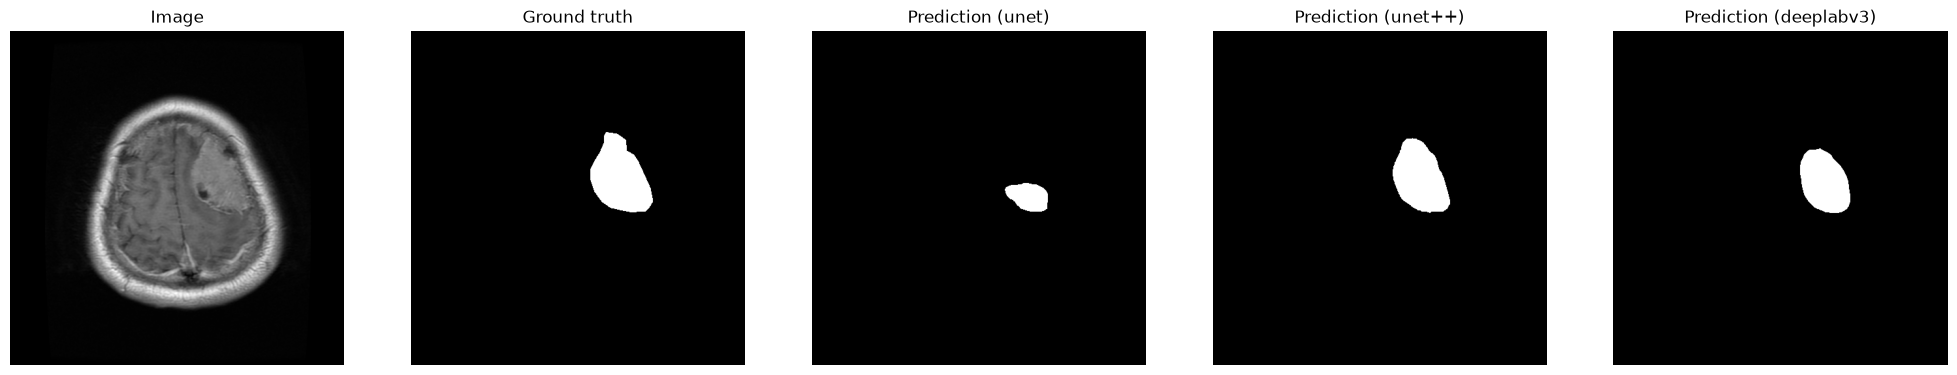

In [54]:
x = preprocessing(np.array(image)).to(device)

mask_pred_unet, prob = predict(model=models["unet"], x=x)
mask_pred_unetpp, prob = predict(model=models["unet++"], x=x)
mask_pred_deeplabv3, prob = predict(model=models["deeplabv3"], x=x)

image_np = np.array(image)                       
img_show  = Image.fromarray(image_np).convert("L").resize(SIZE, Image.Resampling.BICUBIC)
mask_show = Image.fromarray(np.array(mask_real)).convert("L").resize(SIZE, Image.Resampling.NEAREST)


fig, ax = plt.subplots(1, 5, figsize=(25, 5))
ax[0].imshow(img_show, cmap="gray");   ax[0].set_title("Image")
ax[1].imshow(mask_show, cmap="gray");  ax[1].set_title("Ground truth")
ax[2].imshow(mask_pred_unet, cmap="gray");  ax[2].set_title("Prediction (unet)")
ax[3].imshow(mask_pred_unetpp, cmap="gray");  ax[3].set_title("Prediction (unet++)")
ax[4].imshow(mask_pred_deeplabv3, cmap="gray");  ax[4].set_title("Prediction (deeplabv3)")
for a in ax: a.axis("off")
plt.show()

In [61]:
image = Image.open("data/splits/test/images/breast_1_87.png")
mask_real = Image.open("data/splits/test/masks/breast_1_87_mask.png")


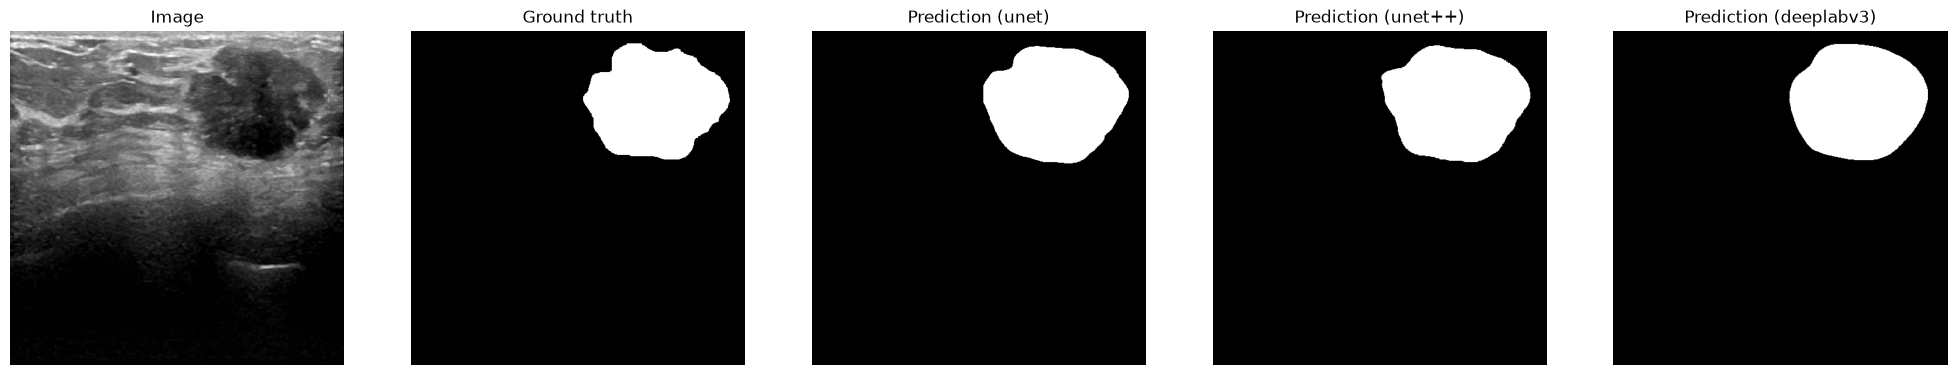

In [62]:
x = preprocessing(np.array(image)).to(device)

mask_pred_unet, prob = predict(model=models["unet"], x=x)
mask_pred_unetpp, prob = predict(model=models["unet++"], x=x)
mask_pred_deeplabv3, prob = predict(model=models["deeplabv3"], x=x)

image_np = np.array(image)                       
img_show  = Image.fromarray(image_np).convert("L").resize(SIZE, Image.Resampling.BICUBIC)
mask_show = Image.fromarray(np.array(mask_real)).convert("L").resize(SIZE, Image.Resampling.NEAREST)


fig, ax = plt.subplots(1, 5, figsize=(25, 5))
ax[0].imshow(img_show, cmap="gray");   ax[0].set_title("Image")
ax[1].imshow(mask_show, cmap="gray");  ax[1].set_title("Ground truth")
ax[2].imshow(mask_pred_unet, cmap="gray");  ax[2].set_title("Prediction (unet)")
ax[3].imshow(mask_pred_unetpp, cmap="gray");  ax[3].set_title("Prediction (unet++)")
ax[4].imshow(mask_pred_deeplabv3, cmap="gray");  ax[4].set_title("Prediction (deeplabv3)")
for a in ax: a.axis("off")
plt.show()